In [151]:
import datetime as dt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import sqlite3
import warnings
from matplotlib.lines import Line2D

In [152]:
warnings.filterwarnings('ignore',category=pd.errors.PerformanceWarning)

In [153]:
Colors = {1:'#000000',
2:'#E69F00',
3:'#56B4E9',
4:'#009E73',
5:'#F0E442',
6:'#0072B2',
7:'#D55E00',
8:'#CC79A7',
9:'#1F77B4',
10:'#AEC7E8',
11:'#FF7F0E',
12:'#FFBB78',
13:'#2CA02C',
14:'#98DF8A',
15:'#D62728',
16:'#FF9896',
17:'#9467BD',
18:'#C5B0D5',
19:'#8C564B',
20:'#C49C94',
21:'#E377C2',
22:'#F7B6D2',
23:'#7F7F7F',
24:'#C7C7C7',
25:'#BCBD22',
26:'#DBDB8D',
27:'#17BECF',
28:'#9EDAE5'}

Markers = {1: 'o',
 2: '^',
 3: 's',
 4: '*',
 5: '>',
 6: 'v',
 7: '+',
 8: 'X',
 9: '<',
 10: 'p',
 11: '8',
 12: 'd',
 13:'P',
 14:'D',
 15:'o',
 16:'^'}

Lines = {1: '-',
 2: '--',
 3: '-,',
 4: ':',
 5: '-',
 6: '--',
 7: '-,',
 8: ':',
 9: '-',
 10: '--',
 11: '-,',
 12: ':',
 13: '-',
 14: '--',
 15: '-,',
 16: ':'}

## Additional indexes

In [154]:
# DevMap = {
# "Accroc":"Winter",
# "Adv08_0008":"Winter",
# "Anapurna":"Winter",
# "Ararat":"Spring",
# "Atlanta":"Spring",
# }

# TestSetMap = {
# 'Turretfield2024':'WWHI',
# 'Turretfield2024CvKittyhawkSow15-May':'WWHI',
# 'Turretfield2024CvScepterSow16-Apr':'WWHI',
# }

# DevCols = {"Spring":"Orange",
#            "Winter":"Blue"}

# TestSetAlphas = {"WWHI":1.0,
#                  "GxExM":0.4,
#                  "TestSet":0.1,
#                  "FAR":0.1}

# TestSetMarkers = {"WWHI":'s',
#                  "GxExM":'o',
#                  "TestSet":'^',
#                  "FAR":'v'}

# TestSetSizes = {"WWHI":10,
#                  "GxExM":50,
#                  "TestSet":100,
#                  "FAR":200}

# plot_order = {
#     'FAR': 0,
#     'TestSet': 1,
#     'GxExM': 2,
#     'WWHI': 3
# }

[     'Blitz',       'Bolt', 'Greenfield', 'Hallmarkxt',     'Jumbo2',
     'Digger',        'Ace',     'Nugget',  'Boomer',  'Cipal0901',  'Cipal1504',  'Cipal1701',   'Commando',      'Flash',
      'Giant',  'Hurricane', 'Indianhead',      'Jumbo',    'Matilda',
     'Nipper', 'Northfield',    'Terrier',   'Kelpiext']

['Blitz',
 'Bolt',
 'Greenfield',
 'Hallmarkxt',
 'Jumbo2',
 'Digger',
 'Ace',
 'Nugget',
 'Boomer',
 'Cipal0901',
 'Cipal1504',
 'Cipal1701',
 'Commando',
 'Flash',
 'Giant',
 'Hurricane',
 'Indianhead',
 'Jumbo',
 'Matilda',
 'Nipper',
 'Northfield',
 'Terrier',
 'Kelpiext']

## Graphing functions

In [155]:
def add_plot_legend(ax=None):

    if ax is None:
        ax = plt.gca()

    dev_handles = [
        Line2D([0], [0],
               marker='o',
               linestyle='None',
               color=colour,
               markersize=8,
               label=dev)
        for dev, colour in DevCols.items()
    ]

    test_handles = [
        Line2D([0], [0],
               marker=TestSetMarkers[test],
               linestyle='None',
               color='black',
               alpha=TestSetAlphas[test],
               markersize=8,
               label=test)
        for test in TestSetMarkers
    ]

    leg1 = ax.legend(
        handles=dev_handles,
        title="Development",
        loc="upper left",
        bbox_to_anchor=(1.02, 1.00)
    )

    ax.add_artist(leg1)

    ax.legend(
        handles=test_handles,
        title="Test Set",
        loc="upper left",
        bbox_to_anchor=(1.02, 0.65)
    )

    plt.subplots_adjust(right=0.8)

In [156]:
def plotxy(experiments,xvar,yvar,data,addLeg = True,ncols=np.nan,cult_cols=False):

    fig, ax = plt.subplots()
    cpos=1
    mpos=1
    #experiments = experiments.sort_values(key=lambda s: s.map(lambda e: plot_order[TestSetMap[e]]))
    for e in experiments:
        plotData = data.loc[data.Experiment==e,:]
        xdata = pd.to_numeric(plotData.loc[:,xvar])
        ydata = pd.to_numeric(plotData.loc[:,yvar])
        if cult_cols==False:
            plt.plot(xdata,ydata,Markers[mpos],color=Colors[cpos],label=e)
            cpos+=1
            mpos+=1
            if mpos>16:
                mpos=1
            if cpos>28:
                cpos=1
        else:
            cultivars =  plotData.loc[:,"Wheat.SowingData.Cultivar"]
            colors = cultivars.map(lambda c: DevCols[DevMap[c]])
            e_marker = TestSetMarkers[TestSetMap[e]]
            e_alpha = TestSetAlphas[TestSetMap[e]]
            e_size = TestSetSizes[TestSetMap[e]]
            plt.scatter(xdata,ydata,c=colors, marker=e_marker,alpha = e_alpha,s = e_size)
            add_plot_legend(ax)
            addLeg = False
    if addLeg == True:
        if np.isnan(ncols):
             ncols = np.ceil(experiments.size/17)
        plt.legend(bbox_to_anchor=(1.15, 1),numpoints=1,ncols=ncols)
    plt.ylabel(yvar)
    plt.xlabel(xvar)

# Read Data

In [157]:
MasterfilePaths = [#r'C:\GitHubRepos\ApsimX\Prototypes\Lentil\Lentil.db',
    r'C:\GitHubRepos\ApsimX\Prototypes\Lentil\FAHMA\FAHMA_Lentil.db',
    r'C:\GitHubRepos\ApsimX\Prototypes\Lentil\NaPA\2019_NSW_Greenethorpe_Mixed_Detailed.db',
    r'C:\GitHubRepos\ApsimX\Prototypes\Lentil\NaPA\2022_Vic_Kalkee_Lentil_Detailed.db',
    r'C:\GitHubRepos\ApsimX\Prototypes\Lentil\NaPA\2022_SA_Riverton_Lentil_Detailed.db',
    r'C:\GitHubRepos\ApsimX\Prototypes\Lentil\NaPA\2022_NSW_WaggaWagga_Lentil_Detailed.db',
    r'C:\GitHubRepos\ApsimX\Prototypes\Lentil\NaPA\2022_NSW_Methul_Lentil_Satellite.db',
    r'C:\GitHubRepos\ApsimX\Prototypes\Lentil\NaPA\2022_Vic_Ouyen_Lentil_Satellite.db',
    r'C:\GitHubRepos\ApsimX\Prototypes\Lentil\NaPA\2022_NSW_RankinsSprings_Lentil_Satellite.db',
    r'C:\GitHubRepos\ApsimX\Prototypes\Lentil\NaPA\2022_SA_Warnertown_Lentil_Satellite.db',
    r'C:\GitHubRepos\ApsimX\Prototypes\Lentil\NaPA\2023_SA_Pinery_Lentil_Detailed.db',
    r'C:\GitHubRepos\ApsimX\Prototypes\Lentil\NaPA\2023_Vic_Dooen_Lentil_Detailed.db',
    r'C:\GitHubRepos\ApsimX\Prototypes\Lentil\NaPA\2023_SA_Warnertown_Lentil_Satellite.db',
    r'C:\GitHubRepos\ApsimX\Prototypes\Lentil\NaPA\2023_Vic_Ouyen_Lentil_Satellite.db',
    r'C:\GitHubRepos\ApsimX\Prototypes\Lentil\NaPA\2023_Qld_Gatton_Mixed_Light.db',
    r'C:\GitHubRepos\ApsimX\Prototypes\Lentil\NaPA\2024_NSW_Greenethorpe_Mixed_NFix.db',
    r'C:\GitHubRepos\ApsimX\Prototypes\Lentil\NaPA\2024_SA_Warnertown_Lentil_Satellite.db',
    r'C:\GitHubRepos\ApsimX\Prototypes\Lentil\NaPA\2024_Vic_Walpeup_Lentil_Satellite.db']

In [158]:
allSimulations = {}
for filePath in MasterfilePaths:
    fileName = filePath.split('\\')[-1].split('.')[0].replace('_master','')
    con = sqlite3.connect(filePath)
    Simulations = pd.read_sql("Select * from _Simulations",con)
    con.close()
    Simulations.set_index('ID',inplace=True)
    Simulations.sort_index(inplace=True)
    Simulations.sort_index(inplace=True, axis=1)
    allSimulations[fileName] = Simulations
Simulations = pd.concat(allSimulations.values(),keys=allSimulations.keys(),names=['File','ID']) 

In [159]:
# SensibilityFolders = ['CO2AndTranspirationEfficiency',
# 'CO2AndTemperatureInteractions',
# 'ProteinAccumulation',
# 'LeafAppearance',
# 'TerminalWaterStress',
# 'DetailedDynamics']

In [160]:
allHarvestPred = {}
for filePath in MasterfilePaths:
    fileName = filePath.split('\\')[-1].split('.')[0].replace('_master','')
    con = sqlite3.connect(filePath)
    HarvestPred = pd.read_sql("Select * from HarvestReport",con).dropna(axis=1,how='all')
    con.close()
    HarvestPred.loc[:,'SimulationName'] = [Simulations.loc[(fileName,x),'Name'] for x in HarvestPred.SimulationID]
    HarvestPred.set_index(['SimulationName','Clock.Today'],drop=False,inplace=True)
    HarvestPred.sort_index(inplace=True)
    HarvestPred.sort_index(inplace=True,axis=1)

    # Filter outputs from sensibility tests
    if 'FolderName' not in HarvestPred:
        HarvestPred.loc[:,'FolderName'] = ''
    #validationFilter = [x not in SensibilityFolders for x in HarvestPred.FolderName]
    #HarvestPred = HarvestPred.loc[validationFilter,:].copy()
    HarvestPred.dropna(how='all',axis=1,inplace=True)
    HarvestPred.loc[:,'Lentil.SowingData.Cultivar'] = [x.title() for x in HarvestPred.loc[:,'Lentil.SowingData.Cultivar']]
    #validationFilter = [x not in SensibilityFolders for x in HarvestPred.FolderName]
    #HarvestPred = HarvestPred.loc[validationFilter,:].copy()
    HarvestPred.dropna(how='all',axis=1,inplace=True)

    # Replace Experiment with values that have had folder name pathed in where no experiment is present
    HarvestPred.loc[[x is None for x in HarvestPred.Experiment],'Experiment'] = HarvestPred.loc[[x is None for x in HarvestPred.Experiment],'FolderName']
    allHarvestPred[fileName] = HarvestPred
HarvestPred = pd.concat(allHarvestPred.values(),keys=allHarvestPred.keys(),names=['File','SimulationName','Clock.Today'])
HarvestPred.loc[:,'File'] = HarvestPred.index.get_level_values(0)

In [161]:
# fill missing experiment values with simulation name
sim_names = pd.Series(
    HarvestPred.index.get_level_values("SimulationName"),
    index=HarvestPred.index
)

HarvestPred["Experiment"] = (
    HarvestPred["Experiment"]
    .replace(r"^\s*$", pd.NA, regex=True)
    .fillna(sim_names)
)

In [162]:
Experiments = list(HarvestPred.loc[:,'Experiment'].drop_duplicates().values)
Folders = list(HarvestPred.loc[:,'FolderName'].drop_duplicates().values)

In [163]:
allDailyPred = {}
for filePath in MasterfilePaths:
    fileName = filePath.split('\\')[-1].split('.')[0].replace('_master','')
    con = sqlite3.connect(filePath)
    DailyPred = pd.read_sql("Select * from AnalysisReport",con)
    con.close()
    DailyPred.loc[:,'SimulationName'] = [Simulations.loc[(fileName,x),'Name'] for x in DailyPred.SimulationID]
    DailyPred.set_index(['SimulationName','Clock.Today'],drop=False,inplace=True)
    DailyPred.sort_index(inplace=True)
    DailyPred.sort_index(inplace=True,axis=1)
    if 'FolderName' not in DailyPred:
        DailyPred.loc[:,'FolderName'] = ''
    #validationFilter = [x not in SensibilityFolders for x in DailyPred.FolderName]
    #DailyPred = DailyPred.loc[validationFilter,:].copy()
    DailyPred.dropna(how='all',axis=1,inplace=True)
    #Replace Experiment with values that have had folder name pathed in where no experiment is present
    #DailyPred.loc[:,'Experiment'] = [HarvestPred.loc[x,'Experiment'] for x in DailyPred.index.get_level_values(0)]
    DailyPred.loc[[x is None for x in DailyPred.Experiment],'Experiment'] = DailyPred.loc[[x is None for x in DailyPred.Experiment],'FolderName']
    allDailyPred[fileName] = DailyPred
DailyPred = pd.concat(allDailyPred.values(),keys=allDailyPred.keys(),names=['File','SimulationName','Clock.Today'])

# Calculate running mean met variables

In [164]:
simulations = DailyPred.index.get_level_values(0).drop_duplicates()
RunningMeans = pd.DataFrame(index = DailyPred.index)
MetVars = ['IWeather.MaxT',
'IWeather.MinT',
'IWeather.Radn']

def running_mean(inp,span):
    return [sum(x)/len(x) for x in (inp[max(0,i-span):i] for i in range(1, len(inp)+1))]

for mv in MetVars:
    for s in simulations:
        inp = list(DailyPred.loc[s,mv].values)
        RunningMeans.loc[s,mv] = running_mean(inp,15)

RunningMeans.loc[:,'Lentil.Phenology.Stage'] = DailyPred.loc[:,'Lentil.Phenology.Stage'] 

# Sort some indexing

In [165]:
SowIndices = [#'IWeather.Latitude',
    #'IWeather.Longitude',
    # 'LocationInfo.Script.Country',
    # 'LocationInfo.Script.Region',
    # 'LocationInfo.Script.State',
    'Lentil.SowingData.Cultivar',
    'Experiment',
    'FolderName']

def getValue(ind,var,HarvestPred):
    try:
        simMask = HarvestPred.SimulationName == ind
        return HarvestPred.loc[simMask,var].values[0]
        #return HarvestPred.loc[ind,var].values[0]
    except:
        return ""
allObserved = {}
for filePath in MasterfilePaths:
    fileName = filePath.split('\\')[-1].split('.')[0].replace('_master','')
    con = sqlite3.connect(filePath)
    observed = pd.read_sql("Select * from Observed",con).dropna(axis=1,how='all')
    con.close()
    observed.loc[:,'SimulationName'] = [Simulations.loc[(fileName,x),'Name'] for x in observed.SimulationID]
    observed.set_index(['SimulationName','Clock.Today'],drop=False,inplace=True)
    observed.sort_index(inplace=True)
    observed.sort_index(inplace=True,axis=1)
    for s in SowIndices:
        observed.loc[:,s] = [getValue(x,s,HarvestPred) for x in observed.index.get_level_values(0)]
    allObserved[fileName] = observed
Observed = pd.concat(allObserved.values(),keys=allObserved.keys(),names=['File','SimulationName','Clock.Today'])

def subtract(a,b):
    if np.isnan(b):
        b = 0
    return a - b

#Observed.loc[:,'Lentil.AboveGroundLive.Wt'] = [subtract(Observed.iloc[x,:]['Wheat.AboveGround.Wt'], Observed.iloc[x,:]['Wheat.Leaf.Dead.Wt']) for x in range(Observed.index.size)]

In [166]:
MasterIndexVars = ['Clock.Today',
'IWeather.MaxT',
'IWeather.MinT',
'IWeather.Radn',
'Lentil.DaysAfterSowing',
'Lentil.Phenology.AccumulatedTT',
'Lentil.Phenology.Stage',
'Lentil.Phenology.Photoperiod']

for iv in MasterIndexVars:
    Observed.loc[:,iv] = DailyPred.reindex(Observed.index).loc[:,iv]    

In [167]:
for iv in MetVars:
    Observed.loc[:,'RunningMean_'+iv] = RunningMeans.reindex(Observed.index).loc[:,iv]  
    DailyPred.loc[:,'RunningMean_'+iv] = RunningMeans.reindex(DailyPred.index).loc[:,iv]  

In [168]:
# MasterIndexVarsHarv = ['SimulationID','SimulationName']

# for iv in MasterIndexVarsHarv:
#     Observed[iv] = HarvestPred.reindex(Observed.index).loc[:,iv]  


# def setvar(x):
#     if np.isnan(Observed.loc[x,'Wheat.Population'].values[0]):
#         try:
#             if ~np.isnan(HarvestPred.loc[x,'Wheat.SowingData.Population'].values[0]):
#                 Observed.loc[x,'Wheat.Population'] = HarvestPred.loc[x,'Wheat.SowingData.Population'].values[0]
#         except:
#             try:
#                 if ~np.isnan(HarvestPred.loc[(x[0],x[1]),'Wheat.SowingData.Population'].values[0]):
#                     Observed.loc[x,'Wheat.Population'] = HarvestPred.loc[(x[0],x[1]),'Wheat.SowingData.Population'].values[0]
#             except:
#                 do = 'Nothing'

# for x in Observed.index:
#         setvar(x)

# Observed.sort_index(inplace=True)
# Observed.sort_index(inplace=True,axis=1)

In [169]:
# fill missing experiment values with simulation name
sim_names = pd.Series(
    Observed.index.get_level_values("SimulationName"),
    index=Observed.index
)

Observed["Experiment"] = (
    Observed["Experiment"]
    .replace(r"^\s*$", pd.NA, regex=True)
    .fillna(sim_names)
)

Text(0.5, 0, 'Lentil.Phenology.AccumulatedTT')

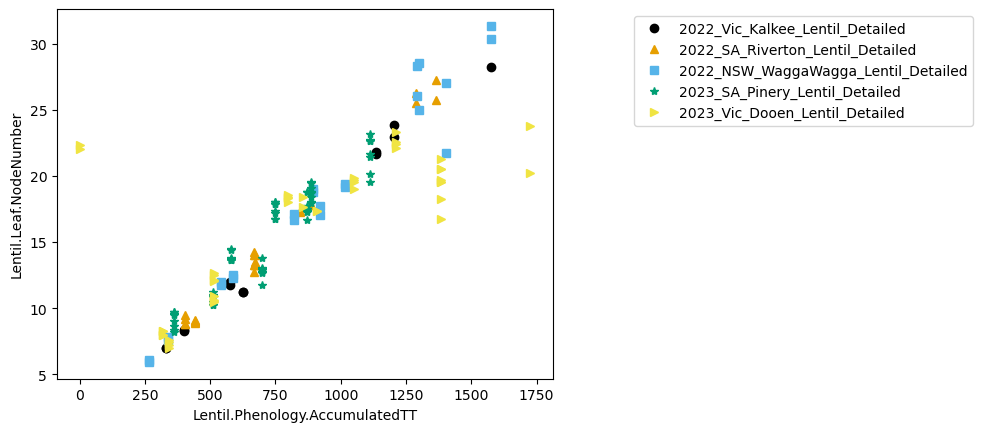

In [170]:
xvar,yvar = 'Lentil.Phenology.AccumulatedTT','Lentil.Leaf.NodeNumber'
experiments = Observed.dropna(subset=[xvar,yvar]).Experiment.drop_duplicates()
data = Observed

fig, ax = plt.subplots()
cpos=1
mpos=1
for e in experiments:
    plotData = data.loc[data.Experiment==e,:]
    xdata = pd.to_numeric(plotData.loc[:,xvar])
    ydata = pd.to_numeric(plotData.loc[:,yvar])
    plt.plot(xdata,ydata,Markers[mpos],color=Colors[cpos],label=e)
    cpos+=1
    mpos+=1
    if mpos>16:
        mpos=1
    if cpos>28:
        cpos=1
ncols = np.ceil(experiments.size/17)
plt.legend(bbox_to_anchor=(1.15, 1),numpoints=1,ncols=ncols)
plt.ylabel(yvar)
plt.xlabel(xvar)

C:\Users\Cflhxb\AppData\Local\Temp\ipykernel_15152\2624507074.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.15, 1),numpoints=1,ncols=ncols)


Text(0.5, 0, 'Lentil.DaysAfterSowing')

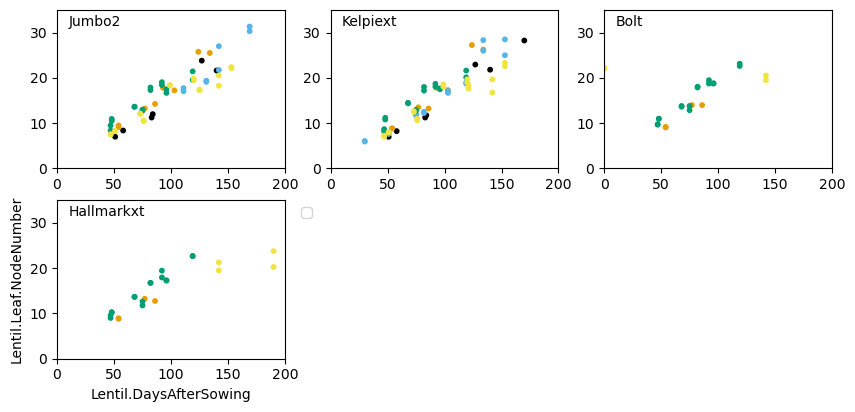

In [171]:
xvar,yvar = 'Lentil.DaysAfterSowing','Lentil.Leaf.NodeNumber'
experiments = Observed.dropna(subset=[xvar,yvar]).Experiment.drop_duplicates()
data = Observed.dropna(subset=[xvar,yvar])
cultivars = data.loc[:,"Lentil.SowingData.Cultivar"].drop_duplicates().values
experiments =  data.loc[:,"Experiment"]
colorMap = {experiment: Colors[i+1] for i, experiment in enumerate(experiments.drop_duplicates().values)}


fig = plt.figure(figsize=(10,7))
pos=1
for c in cultivars:
    ax = fig.add_subplot(3,3,pos)
    plotData = data.loc[data.loc[:,"Lentil.SowingData.Cultivar"]==c,:]
    xdata = pd.to_numeric(plotData.loc[:,xvar])
    ydata = pd.to_numeric(plotData.loc[:,yvar])
    experiments =  plotData.loc[:,"Experiment"]
    colors = [colorMap[e] for e in experiments]
    plt.scatter(xdata,ydata,c=colors,s=10)
    plt.ylim(0,35)
    plt.xlim(0,200)
    plt.text(0.05,0.9,c,transform=ax.transAxes)
    pos+=1
ncols = np.ceil(experiments.size/17)
plt.legend(bbox_to_anchor=(1.15, 1),numpoints=1,ncols=ncols)
plt.ylabel(yvar)
plt.xlabel(xvar)

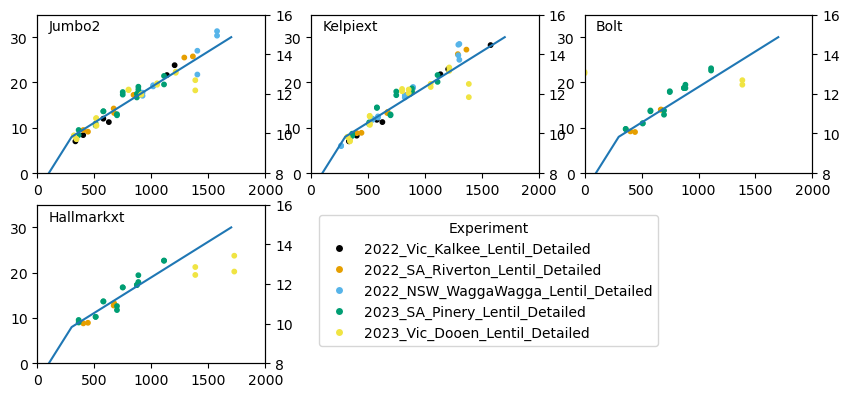

In [172]:
xvar,yvar,Pp = 'Lentil.Phenology.AccumulatedTT','Lentil.Leaf.NodeNumber','Lentil.Phenology.Photoperiod'
experiments = Observed.dropna(subset=[xvar,yvar]).Experiment.drop_duplicates()
data = Observed.dropna(subset=[xvar,yvar,Pp])
cultivars = data.loc[:,"Lentil.SowingData.Cultivar"].drop_duplicates().values
experiments =  data.loc[:,"Experiment"]
colorMap = {experiment: Colors[i+1] for i, experiment in enumerate(experiments.drop_duplicates().values)}

fig = plt.figure(figsize=(10,7))
pos=1
for c in cultivars:
    ax1 = fig.add_subplot(3,3,pos)
    plotData = data.loc[data.loc[:,"Lentil.SowingData.Cultivar"]==c,:]
    xdata = pd.to_numeric(plotData.loc[:,xvar])
    ydata = pd.to_numeric(plotData.loc[:,yvar])
    pp = pd.to_numeric(plotData.loc[:,Pp])
    experiments =  plotData.loc[:,"Experiment"]
    colors = [colorMap[e] for e in experiments]
    ax1.scatter(xdata, ydata, c=colors, s=10)
    ax1.set_ylim(0,35)
    ax1.text(0.05,0.9,c,transform=ax1.transAxes)
    ax2 = ax1.twinx()
    #ax2.scatter(xdata, pp, c=colors, s=1)
    ax2.set_ylim(8,16)
    plt.xlim(0,2000)
    pos+=1

    ax1.plot([100,300,1700],[0,8,30],'-')


legend_handles = [
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        markerfacecolor=colorMap[exp],
        markersize=6,
        label=exp
    )
    for exp in colorMap.keys()
]

fig.legend(
    handles=legend_handles,
    loc='center left',
    bbox_to_anchor=(0.4, 0.5),
    title='Experiment'
)

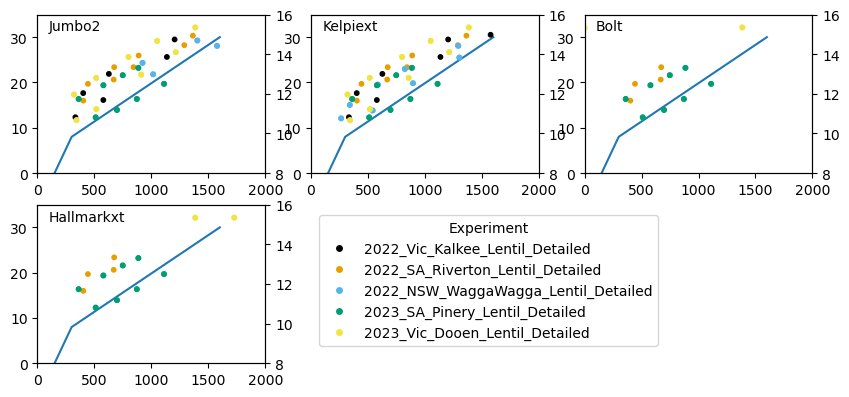

In [173]:
xvar,yvar,Pp = 'Lentil.Phenology.AccumulatedTT','Lentil.Leaf.NodeNumber','Lentil.Phenology.Photoperiod'
experiments = Observed.dropna(subset=[xvar,yvar]).Experiment.drop_duplicates()
data = Observed.dropna(subset=[xvar,yvar,Pp])
cultivars = data.loc[:,"Lentil.SowingData.Cultivar"].drop_duplicates().values
experiments =  data.loc[:,"Experiment"]
colorMap = {experiment: Colors[i+1] for i, experiment in enumerate(experiments.drop_duplicates().values)}

fig = plt.figure(figsize=(10,7))
pos=1
for c in cultivars:
    ax1 = fig.add_subplot(3,3,pos)
    plotData = data.loc[data.loc[:,"Lentil.SowingData.Cultivar"]==c,:]
    xdata = pd.to_numeric(plotData.loc[:,xvar])
    ydata = pd.to_numeric(plotData.loc[:,yvar])
    pp = pd.to_numeric(plotData.loc[:,Pp])
    experiments =  plotData.loc[:,"Experiment"]
    colors = [colorMap[e] for e in experiments]
    #ax1.scatter(xdata, ydata, c=colors, s=10)
    ax1.set_ylim(0,35)
    ax1.text(0.05,0.9,c,transform=ax1.transAxes)
    ax2 = ax1.twinx()
    ax2.scatter(xdata, pp, c=colors, s=10)
    ax2.set_ylim(8,16)
    plt.xlim(0,2000)
    pos+=1

    ax1.plot([150,300,1600],[0,8,30],'-')


legend_handles = [
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        markerfacecolor=colorMap[exp],
        markersize=6,
        label=exp
    )
    for exp in colorMap.keys()
]

fig.legend(
    handles=legend_handles,
    loc='center left',
    bbox_to_anchor=(0.4, 0.5),
    title='Experiment'
)

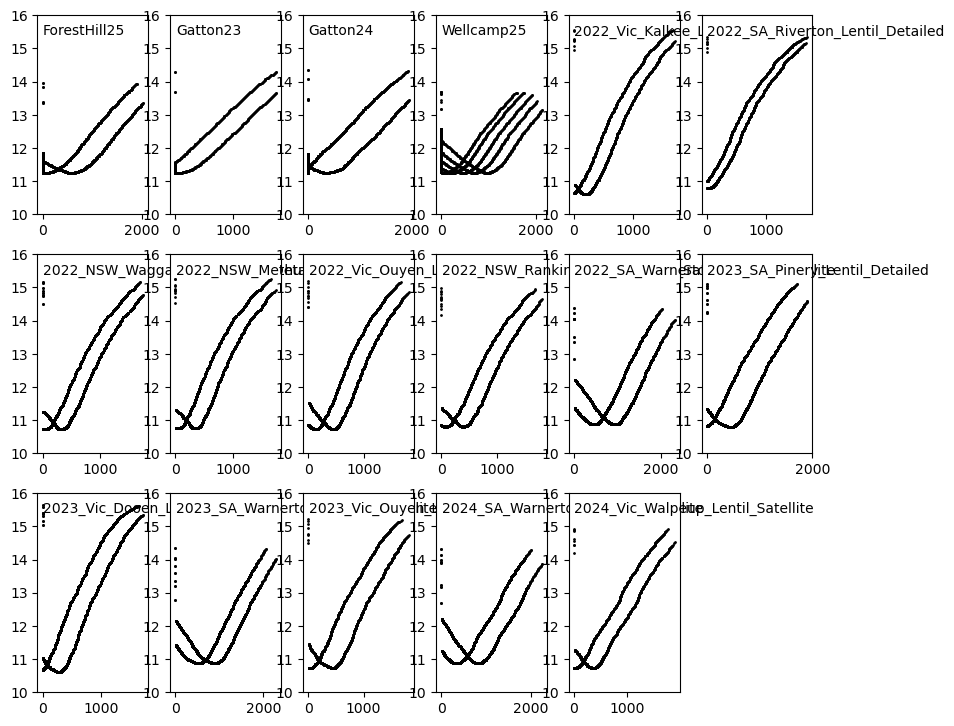

In [174]:
xvar,yvar = 'Lentil.Phenology.AccumulatedTT','Lentil.Phenology.Photoperiod'
experiments = Observed.dropna(subset=[xvar,yvar]).Experiment.drop_duplicates()
data = DailyPred

fig = plt.figure(figsize=(10,15))
pos=1
for e in experiments:
    ax = fig.add_subplot(5,6,pos)
    plotData = data.loc[data.Experiment==e,:]
    xdata = pd.to_numeric(plotData.loc[:,xvar])
    ydata = pd.to_numeric(plotData.loc[:,yvar])
    plt.plot(xdata,ydata,'o',color='k',label=e,ms=1)
    plt.ylim(10,16)
    plt.text(0.05,0.9,e,transform = ax.transAxes)
    pos+=1


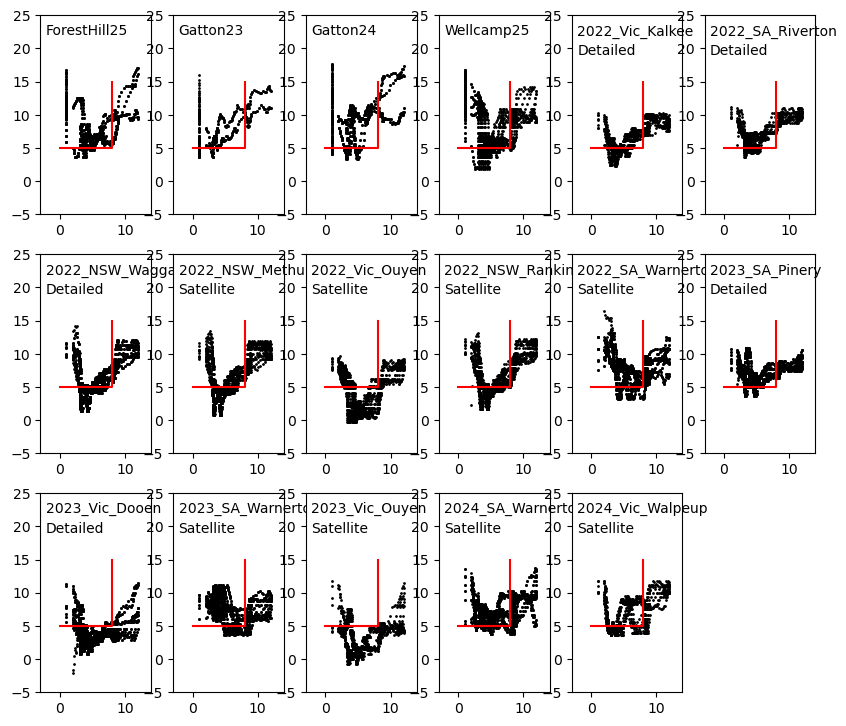

In [175]:
xvar,yvar = 'Lentil.Phenology.Stage','RunningMean_IWeather.MinT'#'IWeather.MinT'
experiments = Observed.dropna(subset=[xvar,yvar]).Experiment.drop_duplicates()
data = DailyPred

fig = plt.figure(figsize=(10,15))
pos=1
for e in experiments:
    ax = fig.add_subplot(5,6,pos)
    plotData = data.loc[data.Experiment==e,:]
    xdata = pd.to_numeric(plotData.loc[:,xvar])
    ydata = pd.to_numeric(plotData.loc[:,yvar])
    plt.plot(xdata,ydata,'o',color='k',label=e,ms=1)
    plt.ylim(-5,25)
    plt.xlim(-3,14)
    labs = e.split("_Lentil_")
    plt.text(0.05,0.9,labs[0],transform = ax.transAxes)
    if len(labs)>1:
        plt.text(0.05,0.8,labs[1],transform = ax.transAxes)
    plt.plot([0,8,8],[5,5,15],'-',color='red')
    pos+=1


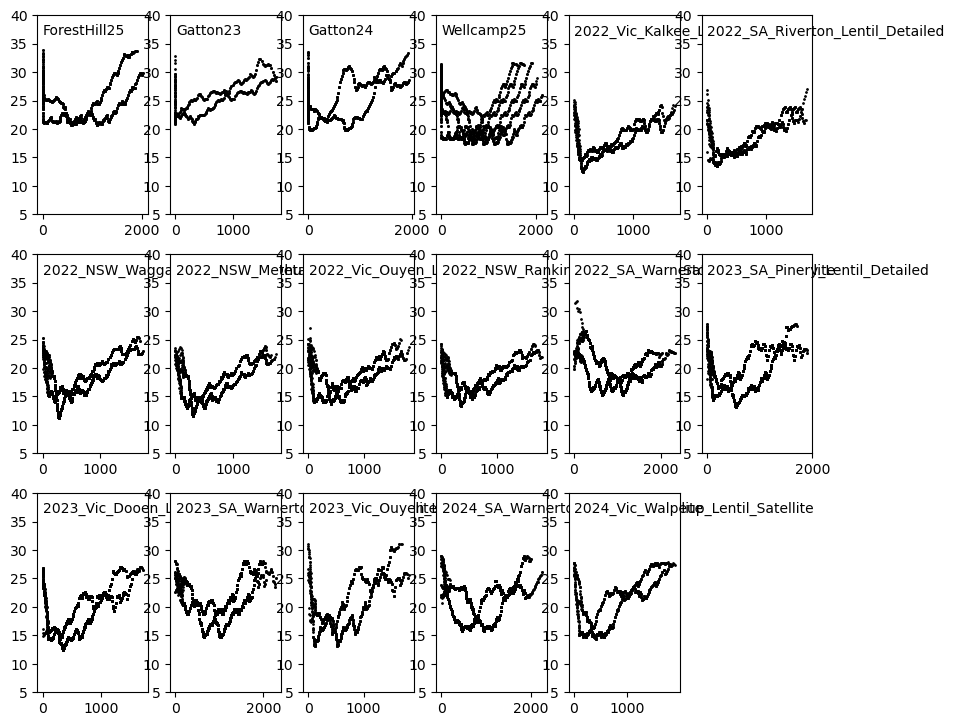

In [176]:

xvar,yvar = 'Lentil.Phenology.AccumulatedTT','RunningMean_IWeather.MaxT'#'IWeather.MaxT'
experiments = Observed.dropna(subset=[xvar,yvar]).Experiment.drop_duplicates()
data = DailyPred

fig = plt.figure(figsize=(10,15))
pos=1
for e in experiments:
    ax = fig.add_subplot(5,6,pos)
    plotData = data.loc[data.Experiment==e,:]
    xdata = pd.to_numeric(plotData.loc[:,xvar])
    ydata = pd.to_numeric(plotData.loc[:,yvar])
    plt.plot(xdata,ydata,'o',color='k',label=e,ms=1)
    plt.ylim(5,40)
    plt.text(0.05,0.9,e,transform = ax.transAxes)
    pos+=1


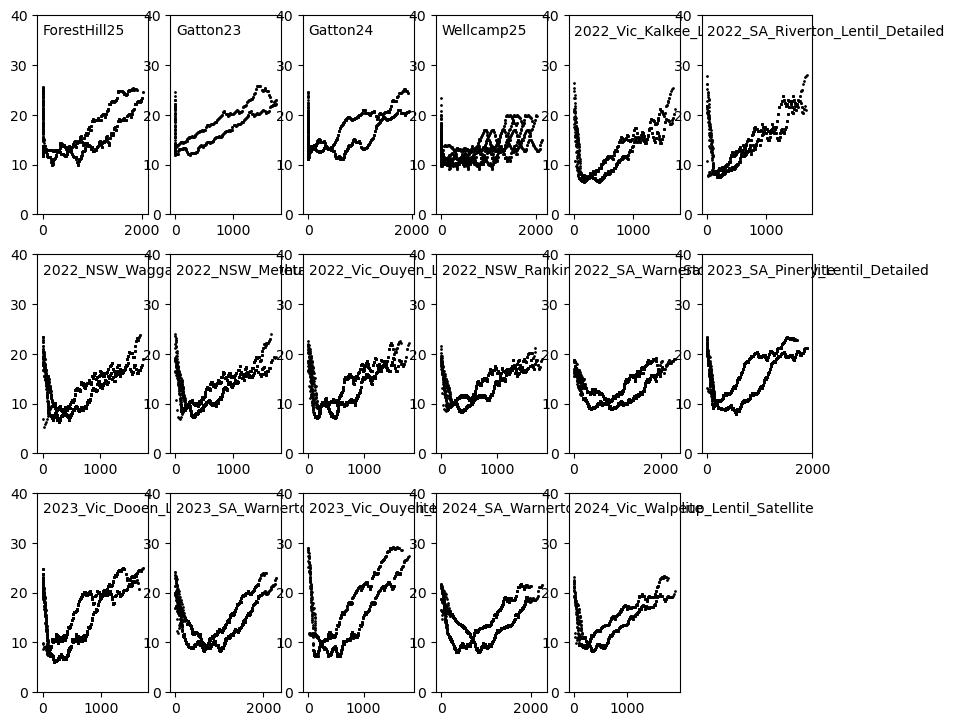

In [177]:
xvar,yvar = 'Lentil.Phenology.AccumulatedTT','RunningMean_IWeather.Radn'#'IWeather.Radn'
experiments = Observed.dropna(subset=[xvar,yvar]).Experiment.drop_duplicates()
data = DailyPred

fig = plt.figure(figsize=(10,15))
pos=1
for e in experiments:
    ax = fig.add_subplot(5,6,pos)
    plotData = data.loc[data.Experiment==e,:]
    xdata = pd.to_numeric(plotData.loc[:,xvar])
    ydata = pd.to_numeric(plotData.loc[:,yvar])
    plt.plot(xdata,ydata,'o',color='k',label=e,ms=1)
    plt.ylim(0,40)
    plt.text(0.05,0.9,e,transform = ax.transAxes)
    pos+=1


In [178]:
DailyPred.loc[:,'IWeather.MinT']

File                               SimulationName                                                          Clock.Today        
FAHMA_Lentil                       ForestHill25TOS1WaterTrtIrrigatedVarietyHallmarkXT                      2025-05-01 00:00:00    10.100000
                                                                                                           2025-05-02 00:00:00     7.700000
                                                                                                           2025-05-03 00:00:00    13.100000
                                                                                                           2025-05-04 00:00:00    11.100000
                                                                                                           2025-05-05 00:00:00    13.100000
                                                                                                                                    ...    
2024_Vic_Walpeup_Lentil_Satellite

In [179]:
# #Make data frame with factor information for each simulation
# FactorList = [ 'Experiment',
#  'Canopy',
#  'Cm',
#  #'Cultivar',
#  'Cv',
#  'Date',
#  #'Durat',
#  'Fungicide',
#  'Grazed',
#  'Irr',
#  'Irrig',
#  'Mgmt',
#  'N',
#  'NRate',
#  'Nit',
#  'Nutrition',
#  'P',
#  'PGR',
#  'Popn',
#  'Removal',
#  'RowSpace',
#  'SD',
#  #'Seeds',
#  'Soil',
#  'Sow',
#  'SowN',
#  'Stubble',
#  'TOS',
#  'TopN',
#  #'Treat',
#  'Treatment',
#  'V',
#  'Water']

# Factors = HarvestPred.loc[:,FactorList].copy()
# Factors.index = Factors.index.droplevel(2)
# Factors.set_index('Experiment',append=True,inplace=True)
# Factors=Factors.reorder_levels(['Experiment','File','SimulationName'])
# Factors.sort_index(inplace=True)
# CondensedFactors = pd.DataFrame(index = Factors.index,columns = ['fName1','fValue1'])
# for s in Factors.index:
#     fs = Factors.loc[s,:].dropna().to_dict()
#     fCount = 1
#     for key, value in fs.items():
#         CondensedFactors.loc[s,'fName'+str(fCount)] = key
#         CondensedFactors.loc[s,'fValue'+str(fCount)] = value
#         fCount +=1
# valueLabs = ['fValue1','fValue2','fValue3','fValue4']
# indexLabs = ['fIndex1','fIndex2','fIndex3','fIndex4']
# CondensedFactors.loc[:,indexLabs]=1

# # put simulation names in as first factor level for sims that are not in a experiment
# for e in Experiments:
#     fValues1 = CondensedFactors.loc[e,'fValue1']
#     if True in pd.isna(fValues1.values):
#         CondensedFactors.loc[e,'fValue1'] = CondensedFactors.loc[e,:].index.values
        
# #assign numeric index to each factor level
# for e in Experiments:
#     folders = CondensedFactors.loc[e,:].index.get_level_values(0).drop_duplicates().values
#     for f in folders:
#         for v in valueLabs:
#             fLevels = CondensedFactors.loc[(e,f),v].drop_duplicates().values
#             if False in pd.isna(fLevels):
#                 levelDic = dict(zip(fLevels,list(range(1,len(fLevels )+1))))
#                 CondensedFactors.loc[(e,f),v.replace('Value','Index')] = [levelDic[x] for x in CondensedFactors.loc[(e,f),v]]

In [180]:
# # convert tiller number calculations to stem number
# def calcStemNumberPerPlant(x):
#     if np.isnan(Observed.loc[x,'Wheat.Leaf.StemNumberPerPlant'].values[0]):
#         return Observed.loc[x,'Wheat.Leaf.StemNumberPerPlant.Total.Tillers'] + 1
#     else:
#         return Observed.loc[x,'Wheat.Leaf.StemNumberPerPlant']
# for x in Observed.index:
#     Observed.loc[x,'Wheat.Leaf.StemNumberPerPlant'] = calcStemNumberPerPlant(x)
    
# #Calculate stem number derivative values

# def FillDataGap(set):
#     a,b,c = set.values[0],set.values[1],set.values[2]
#     if sum(np.isnan([a,b,c])) == 0:
#         return [a,b,c]
#     if sum(np.isnan([a,b,c])) > 1:
#         return [a,b,c]
#     if sum(np.isnan([a,b,c])) == 1:
#         if np.isnan(a):
#             a = b * c
#         if np.isnan(b):
#             b = a/c
#         if np.isnan(c):
#             c = a/b
#         return [a,b,c]
    
# Observed.sort_index(axis=1,inplace=True)
# Observed.sort_index(axis=1,inplace=True)

# a = 'Wheat.Leaf.StemPopulation'
# b = 'Wheat.Leaf.StemNumberPerPlant'
# c = 'Wheat.Population'
# Observed.loc[:,[a,b,c]] = [FillDataGap(Observed.iloc[x,:][[a,b,c]]) for x in range(Observed.index.size)]

# a = 'Wheat.Grain.Wt'
# b = 'Wheat.Grain.Number'
# c = 'Wheat.Grain.Size'
# Observed.loc[:,[a,b,c]] = [FillDataGap(Observed.iloc[x,:][[a,b,c]]) for x in range(Observed.index.size)]